# P04. Gas Giants: Fixed-Q vs Fixed-dt

For a hot gas giant on a short-period orbit, tidal dissipation heats the planet and slowly circularizes its orbit. Two common analytic tide models differ in how their lag depends on tidal frequency:

- **Constant phase lag (fixed-Q)**: the lag angle is the same at every frequency.
- **Constant time lag (fixed-dt)**: the lag time is the same, so the lag angle grows with frequency.

A shorter orbit has a higher tidal frequency, so the two models predict different trends of heating and circularization with orbital period. This notebook compares them for a Saturn-mass planet around a Sun-like star, using three values of $Q$ and three values of the time lag `dt`. Only the planet's tides are computed: the star is a point mass here, and both bodies raise tides in a pair evolution (`calc_pair_evolution`, notebook S03).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import au, year
from TidalPy.Structures import System, build_world, make_tide
from TidalPy.Tides.eccentricity import recommend_eccentricity_truncation
from TidalPy.Utilities.conversions import days2rads

ECCENTRICITY = 0.1  # present-day eccentricity

star = build_world("sol")  # a Sun-like star: one solar mass, radius, and luminosity

# A Saturn-mass planet with one fluid envelope of the MatPack gas placeholder (simple_gas). The analytic tide models
# below do not read the interior, so the envelope only describes the body.
planet = build_world({
    "name": "Hot-Saturn",
    "type": "gasgiant",
    "radius_m": 5.6e7,
    "mass_kg": 5.7e26,
    "layers": {"envelope": {"material": "simple_gas", "radius_fraction": 1.0, "use_tides": True}},
})

system = System("Hot-Saturn System")
system.add_world(star, is_star=True)
system.add_world(planet, tidal_host=star, semi_major_axis=0.05 * au, eccentricity=ECCENTRICITY, synchronous=True)

# The lowest truncation level whose heating stays within 1 percent of the exact value at this eccentricity
truncation = recommend_eccentricity_truncation(ECCENTRICITY)
print("system:", [world.name for world in system])
print("eccentricity truncation level:", truncation)

system: ['Sol', 'Hot-Saturn']
eccentricity truncation level: 6


## Sweeping Orbital Period

For each orbital period, the sweep sets the semi-major axis from the period's mean motion (`calc_semi_major_axis_from_frequency`), spins the planet synchronously at that mean motion (`set_synchronous_rotation`), and reads the tidal heating and the eccentricity rate `de/dt` from the system's one-step evolution. The circularization timescale is $e / |de/dt|$. The classic $e^2$ truncation holds within 1 percent only to an eccentricity of about 0.02, so the sweep uses the level `recommend_eccentricity_truncation` picks for $e = 0.1$.

In [2]:
periods_days = np.logspace(0.0, 1.5, 40)  # 1 to about 32 days


def sweep(tide_model):
    "Tidal heating [W] and circularization timescale [yr] across the orbital periods for one tide model."
    planet.set_tide_model(tide_model)
    planet.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=truncation, obliquity_truncation=0)
    heating = np.empty_like(periods_days)
    circularization_time = np.empty_like(periods_days)
    for i, period_days in enumerate(periods_days):
        semi_major_axis = system.calc_semi_major_axis_from_frequency(planet, days2rads(period_days))
        system.set_semi_major_axis(planet, semi_major_axis)
        system.set_synchronous_rotation(planet)
        evolution = system.calc_world_evolution(planet)
        heating[i] = evolution["tidal_heating"]
        circularization_time[i] = ECCENTRICITY / abs(evolution["de_dt"]) / year
    return heating, circularization_time


q_values = [1.0e4, 1.0e5, 1.0e6]
dt_values = [0.1, 1.0, 10.0]  # [s]
q_curves = {q: sweep(make_tide("fixed_q", fixed_k=[0.5], fixed_q=[q])) for q in q_values}
dt_curves = {dt: sweep(make_tide("fixed_dt", fixed_k=[0.5], fixed_dt=[dt])) for dt in dt_values}

# Power-law slopes against the orbital period (each model's three curves share one slope)
log_periods = np.log10(periods_days)
for label, curves in (("fixed-Q", q_curves[1.0e5]), ("fixed-dt", dt_curves[1.0]),):
    heating_slope = np.polyfit(log_periods, np.log10(curves[0]), 1)[0]
    time_slope = np.polyfit(log_periods, np.log10(curves[1]), 1)[0]
    print(f"{label:8} heating ~ P^{heating_slope:.2f}, circularization timescale ~ P^{time_slope:.2f}")

fixed-Q  heating ~ P^-5.00, circularization timescale ~ P^4.33
fixed-dt heating ~ P^-6.00, circularization timescale ~ P^5.33


Both models rise steeply toward short periods. With $e$ and $k_2$ fixed, the fixed-Q heating scales as $P^{-5}$ and the fixed-dt heating as $P^{-6}$, since the constant time lag's lag angle grows with the tidal frequency. The circularization timescale scales as $P^{13/3}$ for fixed Q and $P^{16/3}$ for fixed dt. A time lag `dt` acts as $Q = 1 / (\omega\,dt)$ at tidal frequency $\omega$, which for these synchronous orbits is about the mean motion, so `dt` = 1 s matches $Q \approx 1.4 \times 10^4$ at a 1 day period and $Q \approx 4.4 \times 10^5$ at 32 days. Its dashed curves therefore cross the solid $Q = 10^5$ curves near a 7 day period.

The dotted gray line marks 4.6 Gyr, the Sun's age. Orbits whose timescale falls below it would likely have circularized by now, unless another body keeps exciting their eccentricity.

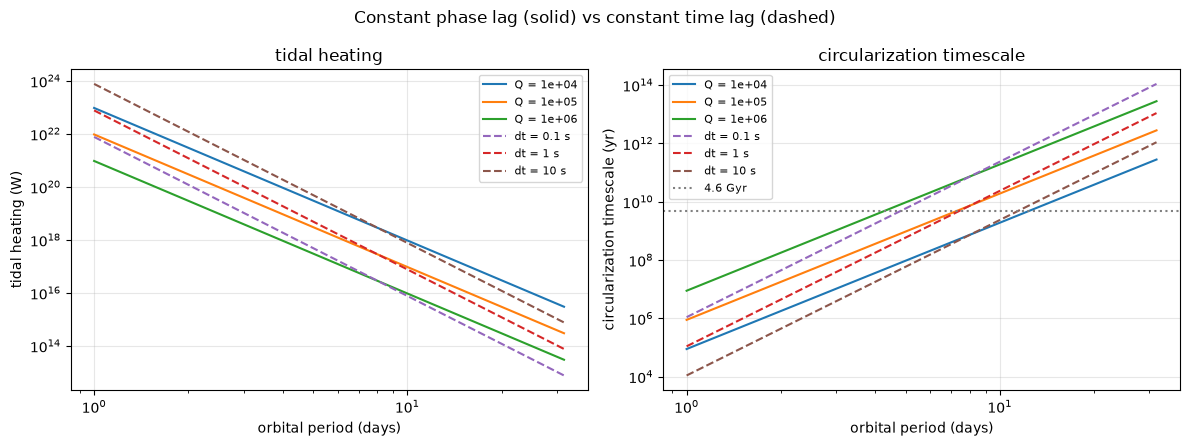

In [3]:
fig, (ax_heating, ax_time) = plt.subplots(1, 2, figsize=(12, 4.5))
for q, color in zip(q_values, ("tab:blue", "tab:orange", "tab:green")):
    ax_heating.loglog(periods_days, q_curves[q][0], color=color, label=f"Q = {q:.0e}")
    ax_time.loglog(periods_days, q_curves[q][1], color=color, label=f"Q = {q:.0e}")
for dt, color in zip(dt_values, ("tab:purple", "tab:red", "tab:brown")):
    ax_heating.loglog(periods_days, dt_curves[dt][0], "--", color=color, label=f"dt = {dt:g} s")
    ax_time.loglog(periods_days, dt_curves[dt][1], "--", color=color, label=f"dt = {dt:g} s")
ax_time.axhline(4.6e9, color="gray", ls=":", label="4.6 Gyr")

ax_heating.set_ylabel("tidal heating (W)")
ax_heating.set_title("tidal heating")
ax_time.set_ylabel("circularization timescale (yr)")
ax_time.set_title("circularization timescale")
for ax in (ax_heating, ax_time):
    ax.set_xlabel("orbital period (days)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Constant phase lag (solid) vs constant time lag (dashed)")
fig.tight_layout()
plt.show()